In [47]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
pi = np.pi

def get_dissipative_part(rho, L1, L2):
        """
        Both L1 and L2 are Hermitian
        """
        C = rho @ L2
        C_dagger = C.conj().T
        C = C - C_dagger #computes [rho, L2]
        C = L1 @ C
        C_dagger = C.conj().T

        return 0.5 * (C + C_dagger)

def Dyn_rho_2qubits(t, rho_vec, 
                    H, L, gamma_d, sigma_1z, sigma_2z):
    rho = np.reshape(rho_vec, (4, 4))

    #coherent part
    C = H @ rho
    C_dagger = C.conj().T
    drhodt = - 1j * (C - C_dagger)

    #Correlated dissipation 
    drhodt += get_dissipative_part(rho, L, L) + \
        gamma_d[0, 0] * get_dissipative_part(rho, sigma_1z, sigma_1z) + \
        gamma_d[0, 1] * get_dissipative_part(rho, sigma_1z, sigma_2z) + \
        gamma_d[1, 0] * get_dissipative_part(rho, sigma_2z, sigma_1z) + \
        gamma_d[1, 1] * get_dissipative_part(rho, sigma_2z, sigma_2z)
        

    return drhodt.flatten()

sigma_mn = np.array([[0, 0], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

sigma_1mn = np.kron(np.eye(2), sigma_mn)
sigma_1pl = sigma_1mn.T

sigma_2mn = np.kron(sigma_mn, np.eye(2))
sigma_2pl = sigma_2mn.T

sigma_1z = np.kron(np.eye(2), sigma_z)
sigma_2z = np.kron(sigma_z, np.eye(2))

In [48]:
#Parameters
delta_1z = 0.5*2*pi# detuning on NV_1
delta_2z = 0 # detuning on NV_2
phi = -pi/2
amp_1 = 2 * np.exp(1j * phi)#using the same notations as in single_qubit simulations
amp_2 = 2* np.exp(1j * phi)#using the same notations as in single_qubit simulations
tau_c = 0.05; Tmax=10

gamma_d_11 = 0.
gamma_d_22 = 0.
gamma_d_12 = 0#should be real
gamma_d = np.array([[gamma_d_11, gamma_d_12], [gamma_d_12, gamma_d_22]])#dephasing matrix

H = 0.5 * delta_1z * sigma_1z + 0.5 * delta_2z * sigma_2z
L = (2 * np.pi)**0.25 * (tau_c**0.5) * (
    amp_1 * sigma_1pl + np.conjugate(amp_1) * sigma_1mn +
    amp_2 * sigma_2pl + np.conjugate(amp_2) * sigma_2mn
       ) 

In [49]:
#QME simulation
t_span = [0, Tmax] 
t_eval = np.linspace(t_span[0], t_span[1], 500)
rho = np.array([[1, 0, 0, 0], 
                [0, 0, 0, 0], 
                [0, 0, 0, 0], 
                [0, 0, 0, 0]],dtype=complex)
rho_vec = rho.flatten()

solution = solve_ivp(lambda t, y: Dyn_rho_2qubits(t, y, H, L, gamma_d, sigma_1z, sigma_2z), 
                     t_span=t_span, 
                     y0=rho_vec, 
                     t_eval=t_eval,  # specify the evaluation points
                     method='RK45', 
                     atol=1e-10, 
                     rtol=1e-10)

sz1_t = np.zeros_like(t_eval, dtype=complex)
sz2_t = np.zeros_like(t_eval, dtype=complex)
sz1sz2_t = np.zeros_like(t_eval, dtype=complex)
ent_entropy_t = np.zeros_like(t_eval, dtype=complex)
threshold = 1e-10

for ind_t in range(len(t_eval)):
    rho_t = np.reshape(solution.y[:,ind_t], (4, 4))
    sz1_t[ind_t] = np.trace(sigma_1z @ rho_t)
    sz2_t[ind_t] = np.trace(sigma_2z @ rho_t)
    sz1sz2_t[ind_t] = np.trace(sigma_1z @ sigma_2z @ rho_t) - sz1_t[ind_t] * sz2_t[ind_t]

    eigenvalues, eigenvectors = np.linalg.eigh(rho_t)
    
    significant_eigenvalues = eigenvalues[eigenvalues > threshold]
    if significant_eigenvalues.size > 0:
        ent_entropy_t[ind_t] = -np.sum(significant_eigenvalues * np.log2(significant_eigenvalues))



81
Stochastic decay rate: [1.03731948], QME decay rate: [1.00265131], tau_c: 0.05, ratio: [1.0345765]


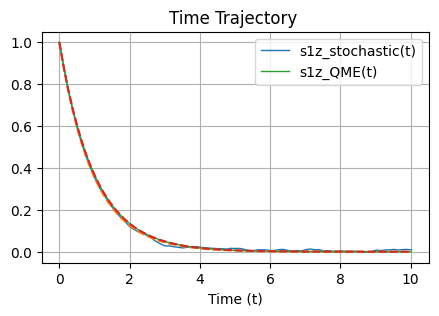

In [50]:
# Stochastic simulation - single qubit
def noise_kernel_time(ti, tj, tau_c):
    # coefficient = 1 / (np.sqrt(2 * np.pi) * tau_c)
    # return coefficient * np.exp(-((ti - tj) ** 2) / (2 * tau_c ** 2))
    
    return np.exp(-((ti - tj) ** 2) / (2 * tau_c ** 2))

def dyn_step_single(s0_vec, h0_vec, delta_t):
    """
    Result of evolution in a static magnetic field h0_vec
    for time delta_t starting from s0_vec.
    """
    h0 = np.linalg.norm(h0_vec)
    if h0 != 0:
        chi = np.dot(s0_vec, h0_vec) / h0
        s_vec = (np.cos(h0 * delta_t) * s0_vec +
                 chi * (1 - np.cos(h0 * delta_t)) * h0_vec / h0 +
                 np.sin(h0 * delta_t) * np.cross(h0_vec / h0, s0_vec))
    else:
        s_vec = s0_vec
    return s_vec

def single_traj(time_grid, delta_t, C, amp, delta):
    G_t = np.random.multivariate_normal(np.zeros(len(time_grid)), C)
    hx_t = np.real(G_t * (amp + np.conjugate(amp)))
    hy_t = np.real(G_t * 1j * (amp - np.conjugate(amp)))
    hz_t = delta * np.ones_like(G_t)

    sx_t = np.zeros(len(time_grid))
    sy_t = np.zeros(len(time_grid))
    sz_t = np.zeros(len(time_grid))
    sz_t[0] = 1

    for idx in range(len(time_grid) - 1):
        h0_vec = np.array([hx_t[idx], hy_t[idx], hz_t[idx]])
        s0_vec = np.array([sx_t[idx], sy_t[idx], sz_t[idx]])
        s_vec = dyn_step_single(s0_vec, h0_vec, delta_t)

        [sx_t[idx + 1], sy_t[idx + 1], sz_t[idx + 1]] = s_vec

    return sx_t, sy_t, sz_t

delta_t = np.sqrt(2 * np.pi) * tau_c 
time_grid = np.arange(0, Tmax + delta_t, delta_t)
print(len(time_grid))

C = np.array([[noise_kernel_time(ti, tj, tau_c) for tj in time_grid] for ti in time_grid])
Num_traj = 10000

sx_avg = np.zeros(len(time_grid))
sy_avg = np.zeros(len(time_grid))
sz_avg = np.zeros(len(time_grid))

for ind in range(Num_traj):
    sx_t, sy_t, sz_t = single_traj(time_grid, delta_t, C, amp_1, delta_1z)
    sx_avg += sx_t
    sy_avg += sy_t
    sz_avg += sz_t
sx_avg = sx_avg / Num_traj
sy_avg = sy_avg / Num_traj
sz_avg = sz_avg / Num_traj

def exp_decay(t, lam):
    return np.exp(-lam * t)

params_st, covariance_st = curve_fit(exp_decay, time_grid, sz_avg, p0=[2])
params_QME, covariance_QME = curve_fit(exp_decay, t_eval, sz1_t, p0=[2])
print(f"Stochastic decay rate: {params_st}, QME decay rate: {params_QME}, tau_c: {tau_c}, ratio: {(2 * np.pi)**0.5 * tau_c * params_st / (delta_t * params_QME)}")

plt.figure(figsize=(5,3))
plt.plot(time_grid, (sz_avg), label='s1z_stochastic(t)', linewidth=1)
plt.plot(time_grid, np.exp(-params_st * time_grid), linestyle='--')
plt.plot(t_eval, (sz1_t), label='s1z_QME(t)', linewidth=1)
plt.plot(time_grid, np.exp(-params_QME * time_grid), linestyle='--')
plt.title('Time Trajectory ')
plt.xlabel('Time (t)')
plt.grid(True)
plt.legend()
plt.show()

In [51]:
def double_traj(time_grid, delta_t, C, amp_1, amp_2, delta_1, delta_2):

    G_t = np.random.multivariate_normal(np.zeros(len(time_grid)), C)

    hx1_t = np.real(G_t * (amp_1 + np.conjugate(amp_1)))
    hy1_t = np.real(G_t * 1j * (amp_1 - np.conjugate(amp_1)))
    hz1_t = delta_1 * np.ones_like(G_t)
    hx2_t = np.real(G_t * (amp_2 + np.conjugate(amp_2)))
    hy2_t = np.real(G_t * 1j * (amp_2 - np.conjugate(amp_2)))
    hz2_t = delta_2 * np.ones_like(G_t)

    sx1_t = np.zeros(len(time_grid))
    sy1_t = np.zeros(len(time_grid))
    sz1_t = np.zeros(len(time_grid))
    sz1_t[0] = 1
    sx2_t = np.zeros(len(time_grid))
    sy2_t = np.zeros(len(time_grid))
    sz2_t = np.zeros(len(time_grid))
    sz2_t[0] = 1

    for idx in range(len(time_grid) - 1):

        h0_vec = np.array([hx1_t[idx], hy1_t[idx], hz1_t[idx]])
        s0_vec = np.array([sx1_t[idx], sy1_t[idx], sz1_t[idx]])
        s_vec = dyn_step_single(s0_vec, h0_vec, delta_t)
        [sx1_t[idx + 1], sy1_t[idx + 1], sz1_t[idx + 1]] = s_vec

        h0_vec = np.array([hx2_t[idx], hy2_t[idx], hz2_t[idx]])
        s0_vec = np.array([sx2_t[idx], sy2_t[idx], sz2_t[idx]])
        s_vec = dyn_step_single(s0_vec, h0_vec, delta_t)
        [sx2_t[idx + 1], sy2_t[idx + 1], sz2_t[idx + 1]] = s_vec

    return sx1_t, sy1_t, sz1_t, sx2_t, sy2_t, sz2_t

sx1_avg = np.zeros(len(time_grid))
sy1_avg = np.zeros(len(time_grid))
sz1_avg = np.zeros(len(time_grid))
sx2_avg = np.zeros(len(time_grid))
sy2_avg = np.zeros(len(time_grid))
sz2_avg = np.zeros(len(time_grid))
sz1sz2c_avg = np.zeros(len(time_grid))

for ind in range(Num_traj):
    sx1_t, sy1_t, sz1_t, sx2_t, sy2_t, sz2_t = double_traj(time_grid, delta_t, C, amp_1, amp_2, delta_1z, delta_2z)
    sx1_avg += sx1_t
    sy1_avg += sy1_t
    sz1_avg += sz1_t
    sx2_avg += sx2_t
    sy2_avg += sy2_t
    sz2_avg += sz2_t
    sz1sz2c_avg += sz1_t * sz2_t
sx1_avg = sx1_avg / Num_traj
sy1_avg = sy1_avg / Num_traj
sz1_avg = sz1_avg / Num_traj
sx2_avg = sx2_avg / Num_traj
sy2_avg = sy2_avg / Num_traj
sz2_avg = sz2_avg / Num_traj
sz1sz2c_avg = sz1sz2c_avg/Num_traj
sz1sz2c_avg = sz1sz2c_avg - sz1_avg * sz2_avg

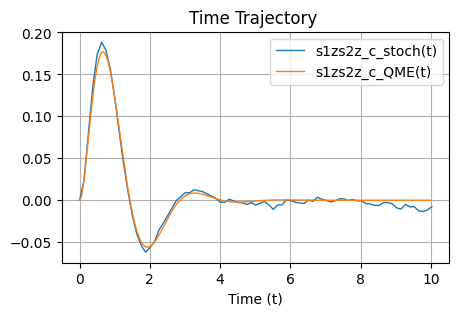

In [52]:
plt.figure(figsize=(5,3))
plt.plot(time_grid, (sz1sz2c_avg), label='s1zs2z_c_stoch(t)', linewidth=1)
plt.plot(t_eval, (sz1sz2_t), label='s1zs2z_c_QME(t)', linewidth=1)
plt.title('Time Trajectory ')
plt.xlabel('Time (t)')
plt.grid(True)
plt.legend()
plt.show()